# Step 1: Exploratory Analysis of Yandex Afisha Data
#### Goal and Objectives

##### Goal:
- Conduct an exploratory data analysis of ticket bookings on the Yandex Afisha service for the period from June 1 to October 31, 2024.

##### Objectives:

- Load the datasets and review their structure.
- Perform data preprocessing.
- Check for explicit and implicit duplicates.
- Convert columns to appropriate data types.
- Analyze the distribution of orders by segments and seasonal changes.
- Study user activity in autumn.
- Identify popular events and partners.
- Perform statistical analysis of the data:
- Average number of orders
- Average time between orders


### Data Description
1. Dataset: `final_tickets_orders_df.csv` - this dataset contains information about all ticket orders made from two types of devices: mobile and desktop.

###### Columns:
- order_id — unique order identifier
- user_id — unique user identifier
- created_dt_msk — order creation date (Moscow time)
- created_ts_msk — order creation date and time (Moscow time)
- event_id — event identifier from the events table
- cinema_circuit — cinema chain. If not applicable, the value is "нет"
- age_limit — age restriction for the event
- currency_code — payment currency (for example, rub for Russian rubles)
- device_type_canonical — device type used to place the order (for example, mobile or desktop)
- revenue — revenue from the order
- service_name — ticket operator name
- tickets_count — number of tickets purchased
- total — total order amount
- days_since_prev — number of days since the previous purchase for each user


 
2. Dataset: `final_tickets_events_df.csv` - this dataset contains information about events, including the city and region of the event, as well as information about the venue.

###### Columns:

- event_id — unique event identifier
- event_name — event name (similar to the field event_name_code in the original database)
- event_type_description — description of the event type
- event_type_main — main event type (for example, theater performance, concert, etc.)
- organizers — event organizers
- region_name — region name
- city_name — city name
- venue_id — unique venue identifier
- venue_name — venue name
- venue_address — venue address


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

In [2]:
tickets_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

In [3]:
tickets_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

The dataset `tickets_orders` contains `14 columns` and `290,849 rows` with information about all ticket orders made from mobile and desktop devices.

After the initial data analysis, the following conclusions were made:

- Column names are already consistent, so no renaming is required.
- Columns `tickets_count`, `age_limit`, `days_since_prev`, and `event_id` can be optimized by reducing memory usage (downcasting).
- Columns `created_dt_msk` and `created_ts_msk` should be converted to the date/datetime type.
- Missing values are present in the `days_since_prev column`. This is expected because if there was no previous purchase, the value is missing.
- The values in all columns match their descriptions.

In [5]:
tickets_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [6]:
tickets_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
tickets_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


The dataset `tickets_events` contains `11 columns` and `22,427 rows` with information about events, including the event location and venue details.

After the initial analysis:
- Column names are consistent and do not need changes.
- Columns `event_id`, `city_id`, and `venue_id` can be optimized by reducing memory usage (downcasting).
- There are no missing values.
- The values in the columns correspond to their descriptions.

In [8]:
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [9]:
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Dataset: `tenge`

This dataset contains `4 columns` and `357 rows` with information about the exchange rate of the Kazakhstani tenge relative to the Russian ruble in 2024.

Initial Data Analysis Conclusions

- Column names are consistent.
- The `date` column should be converted to the date data type.
- Columns `nominal` and `curs` can be optimized by reducing memory usage (downcasting).
- There are no missing values.
- The values in the columns match their descriptions.

# Step 2: Data Preprocessing and Preparation for Analysis

In [11]:
tenge['curs'] = pd.to_numeric(tenge['curs'], downcast = 'float')

In [12]:
tenge['nominal'] = pd.to_numeric(tenge['nominal'], downcast = 'integer')

In [13]:
tenge['data'] = pd.to_datetime(tenge['data'])

In [14]:
tickets_orders['days_since_prev'] = pd.to_numeric(tickets_orders['days_since_prev'],downcast='float')

In [15]:
for column in ['tickets_count','age_limit','event_id']:
    tickets_orders[column] = pd.to_numeric(tickets_orders[column], downcast='integer')

In [16]:
for column in ['created_dt_msk','created_ts_msk']:
    tickets_orders[column]= pd.to_datetime(tickets_orders[column])

In [17]:
tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int32         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int8          
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float64       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int8          
 12  total                  290849 non-null  floa

In [18]:
for column in ['event_id','city_id','venue_id']:
    tickets_events[column] = pd.to_numeric(tickets_events[column], downcast = 'integer')

In [19]:
tickets_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int32 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int32 
 8   venue_id                22427 non-null  int16 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int16(1), int32(2), object(8)
memory usage: 1.6+ MB


In [20]:
tickets_orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

In [21]:
tickets_events.isna().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

In [22]:
tickets_orders.duplicated().sum()

0

In [23]:
tickets_events.duplicated().sum()

0

In [24]:
tenge['cdx'].unique()

array(['kzt'], dtype=object)

In [25]:
tickets_events['event_type_description'].unique()

array(['спектакль', 'балет', 'мюзикл', 'опера', 'концерт', 'шоу', 'ёлка',
       'цирковое шоу', 'событие', 'фестиваль', 'спортивное мероприятие',
       'выставка', 'спорт', 'оперетта', 'экскурсия', 'рок-мюзикл',
       'музыкальный спектакль', 'снегурочка', 'подарок',
       'кукольный спектакль'], dtype=object)

In [26]:
tickets_events['event_type_main'].unique()

array(['театр', 'концерты', 'ёлки', 'другое', 'стендап', 'выставки',
       'спорт'], dtype=object)

In [27]:
tickets_orders['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [28]:
tickets_orders['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [29]:
tickets_orders['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

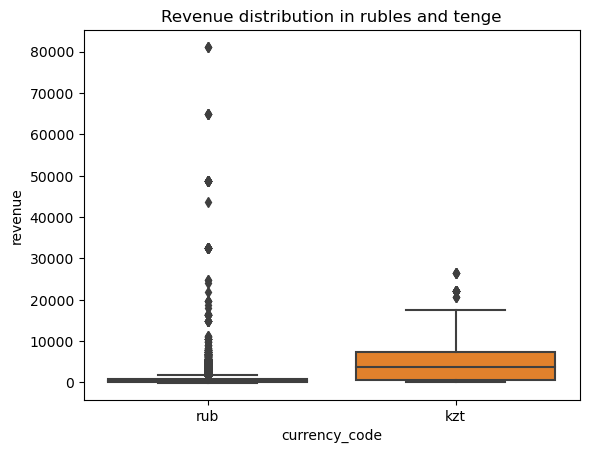

In [30]:
#check for outliners
sns.boxplot(x='currency_code', y = 'revenue', data = tickets_orders)
plt.title('Revenue distribution in rubles and tenge')
plt.show()

In [31]:
tickets_orders.groupby('currency_code')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.1000,3698.83,7397.66,26425.86
rub,285780.0,547.568333,871.524559,-90.76,113.8275,346.10,791.70,81174.54


Revenue Analysis (kzt and rub)

- kzt: Values vary a lot (min = 0, max ≈ 26,426, mean ≈ 4,995, median ≈ 3,699). There are very large values compared to the median, which means there are outliers.
- rub: The distribution is even more extreme (min = -90.76 — negative revenue?, max ≈ 81,175, mean ≈ 547, median = 346). There are clear outliers both at the top and possibly at the bottom.
- Both currencies have outliers, but they are especially noticeable in rub. Maximum values are far above the 75th percentile, and negative values (like -90.76) are also abnormal. The data is not symmetric and requires outlier treatment before analysis.

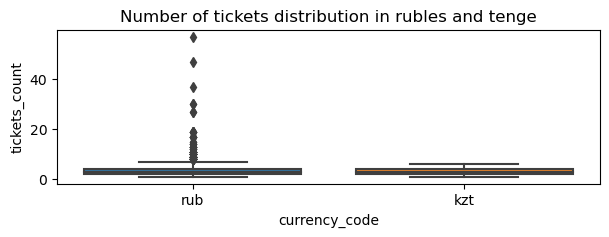

In [32]:
plt.figure(figsize=(7,2))

sns.boxplot(x='currency_code',y='tickets_count',data=tickets_orders)
plt.title('Number of tickets distribution in rubles and tenge')

plt.show()

In [33]:
tickets_orders.groupby('currency_code')['tickets_count'].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,2.762872,1.115558,1.0,2.0,3.0,4.0,6.0
rub,285780.0,2.754077,1.171419,1.0,2.0,3.0,4.0,57.0


General Observations

- For kzt, there are no clear outliers; the data looks fairly uniform.

- For rub, most values are normal, but the maximum value 57 is an outlier. Since the dataset is very large (285,780 rows), single outliers do not significantly affect the mean, so the mean and median are close.

In [34]:
# 2. Prepare for converting KZT
tenge = tenge[['data', 'curs', 'cdx']].copy()
tenge.rename(columns={'data': 'created_dt_msk'}, inplace=True)

# 3.merge
tickets_orders = tickets_orders.merge(tenge[['created_dt_msk', 'curs']], on='created_dt_msk', how='left')

# 4. vectored: revenue_rub
# - if KZT: revenue / 100 * curs
# - if RUB: revenue original
tickets_orders['revenue_rub'] = tickets_orders['revenue']  # first we copy value 
mask_kzt = tickets_orders['currency_code'] == 'kzt'
tickets_orders.loc[mask_kzt, 'revenue_rub'] = tickets_orders.loc[mask_kzt, 'revenue'] / 100 * tickets_orders.loc[mask_kzt, 'curs']


In [35]:
tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int32         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int8          
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float64       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int8          
 12  total                  290849 non-null  floa

In [36]:
tickets_orders['one_ticket_revenue_rub'] = tickets_orders['revenue_rub'] / tickets_orders['tickets_count']

In [37]:
# create column `month`
tickets_orders['month'] = tickets_orders['created_dt_msk'].dt.month

In [38]:
tickets_orders['month'].unique()

array([ 8,  7, 10,  9,  6], dtype=int32)

In [39]:
def season_function(row):
    if row['month']<=8:
        return 'summer'
    else:
        return 'autumn'   

In [40]:
tickets_orders['season'] = tickets_orders.apply(season_function,axis=1)

In [41]:
tickets_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,curs,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN,18.697201,1521.94,380.4850,8,summer
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN,18.341900,289.45,144.7250,7,summer
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0,19.647499,1258.57,314.6425,10,autumn
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN,18.500999,8.49,4.2450,7,summer
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0,19.664801,1390.41,463.4700,10,autumn


In [42]:
tickets_orders.groupby('season')['month'].unique()

season
autumn      [10, 9]
summer    [8, 7, 6]
Name: month, dtype: object

In [43]:
tickets_merge = tickets_orders.merge(tickets_events, on='event_id', how='inner')

In [44]:
tickets_merge.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [45]:
tickets_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int32         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  int8          
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float64       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  int8          
 12  total                   290611

In [46]:
tickets_merge.duplicated().sum()

0

In [47]:
tickets_filtered = tickets_merge[tickets_merge['revenue']<=tickets_merge['revenue'].quantile(0.99)].copy()

In [48]:
rows = tickets_merge.shape[0] - tickets_filtered.shape[0]
print(rows)

2907


In [49]:
tickets_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287704 entries, 0 to 290610
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287704 non-null  int64         
 1   user_id                 287704 non-null  object        
 2   created_dt_msk          287704 non-null  datetime64[ns]
 3   created_ts_msk          287704 non-null  datetime64[ns]
 4   event_id                287704 non-null  int32         
 5   cinema_circuit          287704 non-null  object        
 6   age_limit               287704 non-null  int8          
 7   currency_code           287704 non-null  object        
 8   device_type_canonical   287704 non-null  object        
 9   revenue                 287704 non-null  float64       
 10  service_name            287704 non-null  object        
 11  tickets_count           287704 non-null  int8          
 12  total                   287704 non-

- No missing values or explicit/implicit duplicates were found.

New Columns Created

- `revenue_rub` — revenue converted to a single currency, Russian rubles. Conversion was done using the dataset final_tickets_tenge_df.csv containing the 2024 exchange rate of Kazakhstani tenge to rubles. Values are shown per 100 tenge.
- `one_ticket_revenue_rub` — revenue from the sale of one ticket for the event.
- `month` — extracted the month of the order from the order date.
- Seasonal groups `season`— created categories for seasonality: 'summer', 'autumn', 'winter', 'spring'. Since our dataset only covers June 1 to October 31, 2024, only 'summer' and 'autumn' are included.

# Step 3: Exploratory Data Analysis
#### 3.1. Analysis of Order Distribution by Segments and Seasonal Changes

In [50]:
# number of orders by month
orders_count=tickets_filtered.groupby('month')['order_id'].count()
print(orders_count)

month
6     32666
7     40740
8     44714
9     69681
10    99903
Name: order_id, dtype: int64


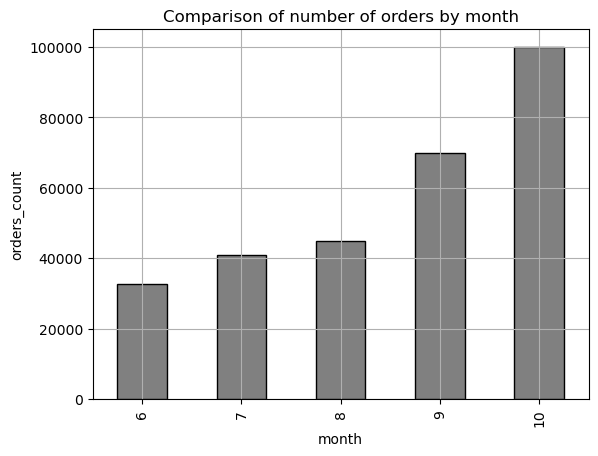

In [51]:
orders_count.plot(kind='bar',
                  title='Comparison of number of orders by month',
                  edgecolor='k',
                  color='grey',
                  ylabel='orders_count')
plt.grid()
plt.show()


In [52]:
event_type = tickets_filtered.groupby('event_type_main')['season'].value_counts(normalize=True).unstack(fill_value=0)
print(event_type)

season             autumn    summer
event_type_main                    
выставки         0.502060  0.497940
другое           0.505767  0.494233
концерты         0.561881  0.438119
спорт            0.862538  0.137462
стендап          0.521126  0.478874
театр            0.640492  0.359508
ёлки             0.861600  0.138400


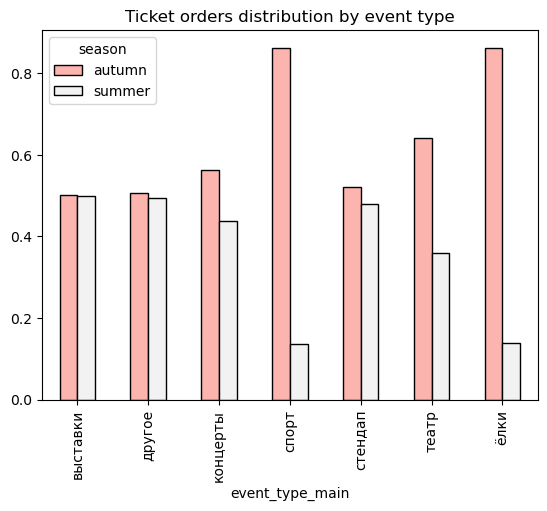

In [53]:
event_type.plot(kind='bar',
                edgecolor='k',
                colormap='Pastel1',                      
                title='Ticket orders distribution by event type')
plt.show()

In [54]:
device_type = tickets_filtered.groupby('device_type_canonical')['season'].value_counts(normalize=True).unstack(fill_value=0)
print(device_type)

season                   autumn    summer
device_type_canonical                    
desktop                0.604411  0.395589
mobile                 0.585726  0.414274


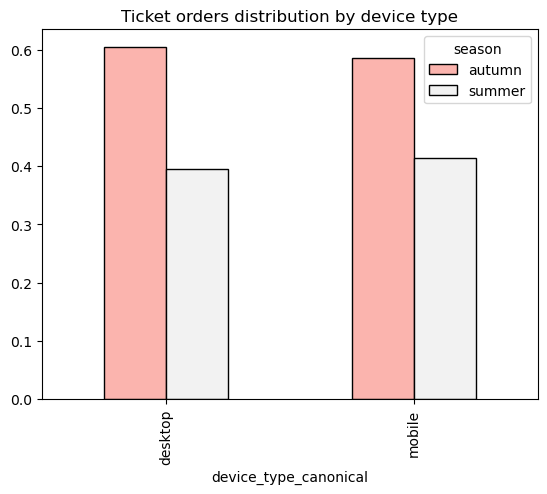

In [55]:
device_type.plot(kind='bar',
                title='Ticket orders distribution by device type',
                edgecolor='k',
                colormap='Pastel1')
plt.show()

In [56]:
age = tickets_filtered.groupby('age_limit')['season'].value_counts(normalize=True).unstack(fill_value=0)

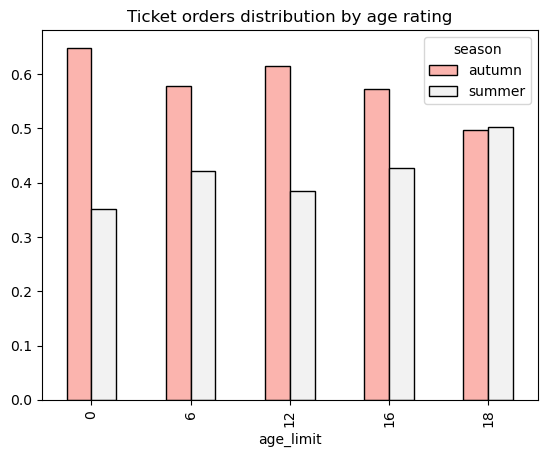

In [57]:
age.plot(kind='bar',
        title='Ticket orders distribution by age rating',
        edgecolor='k',
        colormap='Pastel1')
plt.show()

In [58]:
tickets_filtered.groupby('event_type_main')['revenue'].mean()

event_type_main
выставки    232.871844
другое      245.144182
концерты    776.563751
спорт       165.077123
стендап     672.761390
театр       534.983871
ёлки        769.386578
Name: revenue, dtype: float64

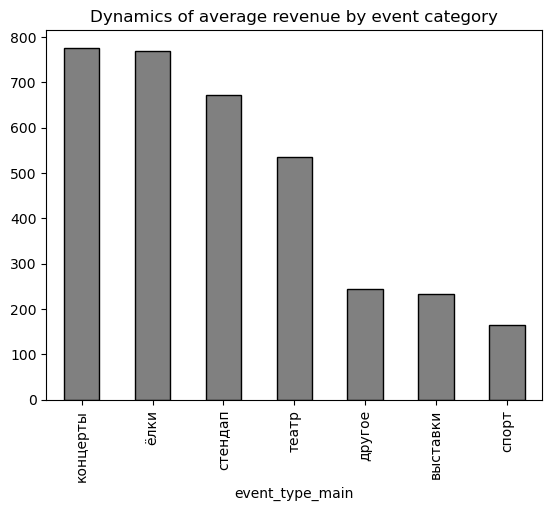

In [59]:
tickets_filtered.groupby('event_type_main')['revenue'].mean().sort_values(ascending=False).plot(kind='bar',
                                                               title='Dynamics of average revenue by event category',
                                                               edgecolor='k',
                                                               color='grey')
plt.show()

In [60]:
one_ticket = tickets_filtered.groupby(['event_type_main','season'])['one_ticket_revenue_rub'].mean().unstack(fill_value=0)
print(one_ticket)

season               autumn      summer
event_type_main                        
выставки          91.066619   86.388607
другое            77.012042   80.660952
концерты         273.777788  297.316161
спорт             49.991234   51.986228
стендап          232.626359  221.284353
театр            179.690876  218.676578
ёлки             234.216151  274.749549


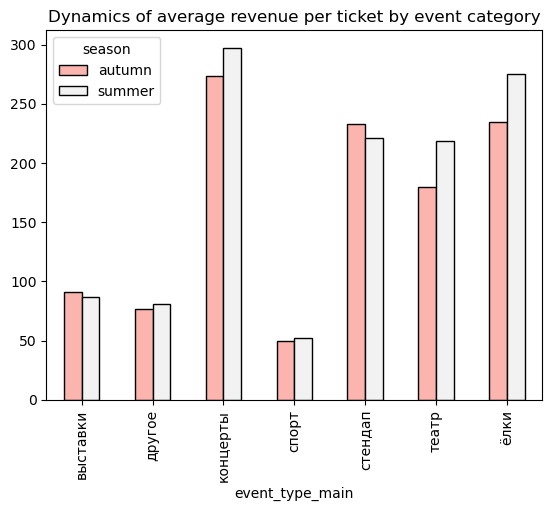

In [61]:
one_ticket.plot(kind='bar',
               title='Dynamics of average revenue per ticket by event category',
               edgecolor='k',
               colormap='Pastel1')
plt.show()

In [62]:
one_ticket.index

Index(['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки'], dtype='object', name='event_type_main')

In [63]:
one_ticket.head()

season,autumn,summer
event_type_main,,
выставки,91.066619,86.388607
другое,77.012042,80.660952
концерты,273.777788,297.316161
спорт,49.991234,51.986228
стендап,232.626359,221.284353


In [64]:
relative_change = (
    (one_ticket['autumn'] - one_ticket['summer']) / one_ticket['summer'] * 100
).round(2)
display(relative_change)

event_type_main
выставки     5.42
другое      -4.52
концерты    -7.92
спорт       -3.84
стендап      5.13
театр      -17.83
ёлки       -14.75
dtype: float64

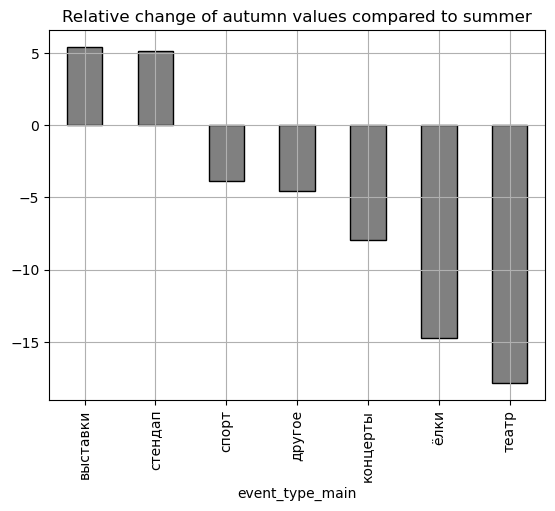

In [65]:
relative_change.sort_values(ascending=False).plot(kind='bar',
                                                 title='Relative change of autumn values compared to summer',
                                                 edgecolor='k',
                                                 color='grey')
plt.grid()
plt.show()


Observations in autumn:

- Increase in total order volume
- Shift in demand towards sports, theater, Christmas tree events, and concerts
- Decrease in average ticket price in most categories

This may indicate:

- Seasonal promotions or price adjustments
- Changes in audience structure
- Growth in popularity of mass or more affordable events

####  3.2. Autumn user activity

In [66]:
autumn_seg = tickets_filtered[(tickets_filtered['month']==9)|(tickets_filtered['month']==10)].copy()
autumn_seg.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
14,4222372,0beb8fc0c0a9ce1,2024-10-21,2024-10-21 14:14:26,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
15,5244622,0e6fa925c5f346f,2024-09-11,2024-09-11 13:34:03,169230,нет,16,rub,desktop,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
16,5244651,0e6fa925c5f346f,2024-09-11,2024-09-11 13:35:58,169230,нет,16,rub,desktop,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
19,4173884,1a7e020ee0b4418,2024-10-11,2024-10-11 18:14:13,169230,нет,16,rub,desktop,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
21,6074399,26068df7451bdb0,2024-10-23,2024-10-23 13:46:01,169230,нет,16,rub,mobile,760.97,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [67]:
autumn_seg['month'].unique()

array([10,  9], dtype=int32)

In [68]:
pivot_seg = pd.pivot_table(autumn_seg,
                           index='created_dt_msk',
                           values=['order_id','user_id','revenue','tickets_count'],
                           aggfunc={'order_id':'count',
                                   'user_id': 'nunique',
                                   'revenue': 'sum',
                                   'tickets_count': 'sum'})
display(pivot_seg)

,order_id,revenue,tickets_count,user_id
created_dt_msk,,,,
2024-09-01,1346,787415.41,3807,569
2024-09-02,1381,752470.39,3709,574
2024-09-03,5112,1203534.11,15298,778
2024-09-04,1774,933984.07,4821,687
2024-09-05,1943,1068736.56,5233,740
...,...,...,...,...
2024-10-27,2862,1507176.29,7925,1036
2024-10-28,2852,1408176.19,7991,987
2024-10-29,2884,1505748.35,8137,1002


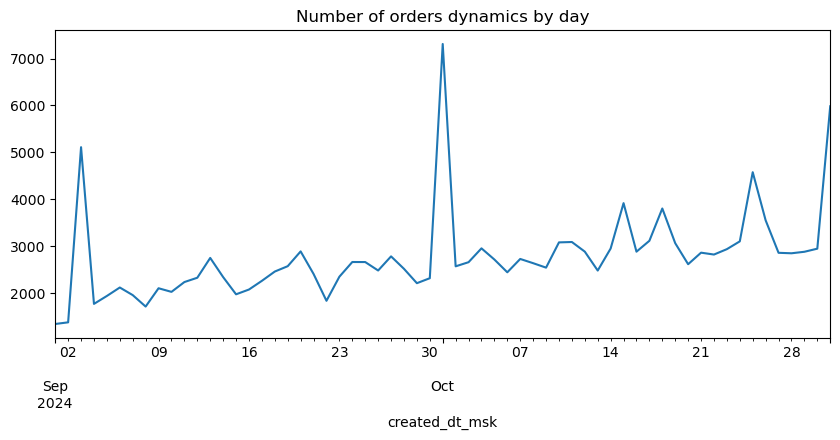

In [69]:
pivot_seg['order_id'].plot(figsize=(10,4),
              title='Number of orders dynamics by day')
plt.show()

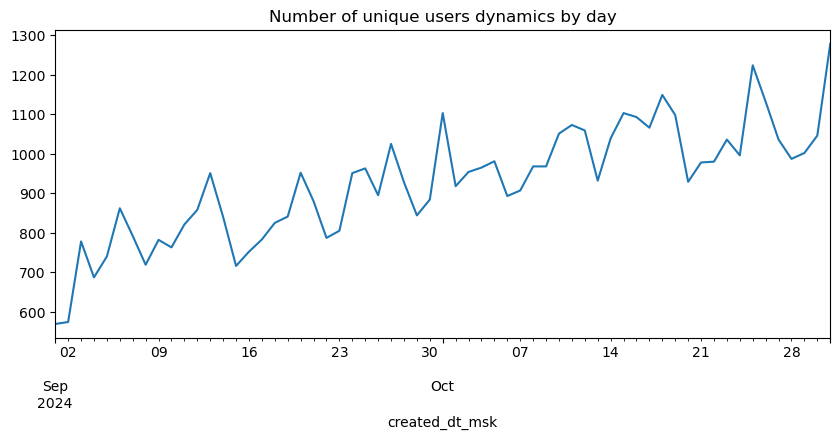

In [70]:
pivot_seg['user_id'].plot(figsize=(10,4),
              title='Number of unique users dynamics by day')
plt.show()

In [71]:
#  count of orders per user
pivot_seg['orders_per_user']= pivot_seg['order_id'] / pivot_seg['user_id']

In [72]:
pivot_seg['cost_one_ticket']= pivot_seg['revenue'] / pivot_seg['tickets_count']

In [73]:
pivot_seg.head()

,order_id,revenue,tickets_count,user_id,orders_per_user,cost_one_ticket
created_dt_msk,,,,,,
2024-09-01,1346,787415.41,3807,569,2.365554,206.833572
2024-09-02,1381,752470.39,3709,574,2.405923,202.876891
2024-09-03,5112,1203534.11,15298,778,6.570694,78.672644
2024-09-04,1774,933984.07,4821,687,2.582242,193.732435
2024-09-05,1943,1068736.56,5233,740,2.625676,204.230185


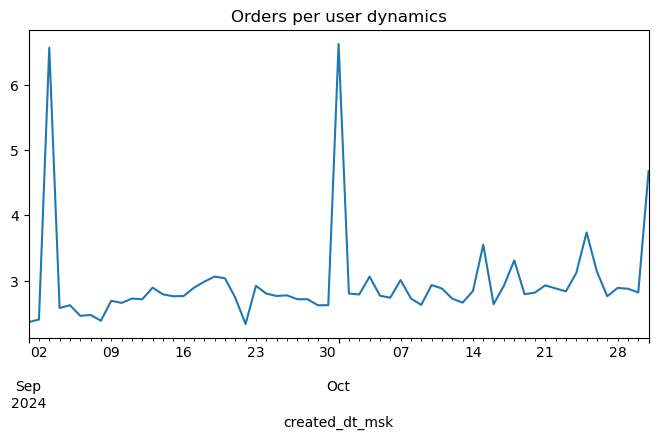

In [74]:
pivot_seg['orders_per_user'].plot(figsize=(8,4))
plt.title('Orders per user dynamics')
plt.show()

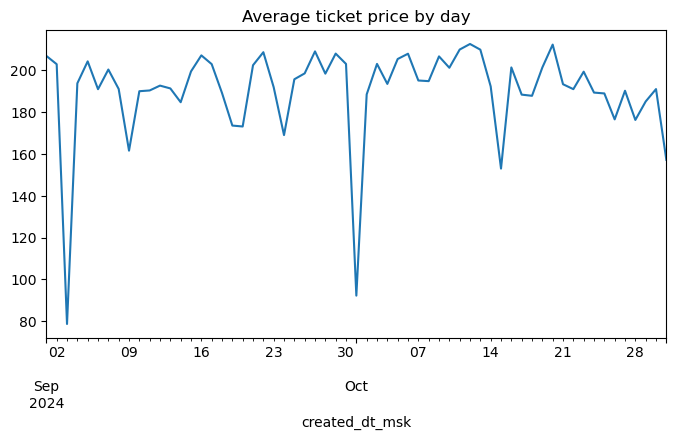

In [75]:
pivot_seg['cost_one_ticket'].plot(figsize=(8,4))
plt.title('Average ticket price by day')
plt.show()

In [76]:
autumn_seg['day_of_week']=autumn_seg['created_dt_msk'].dt.day_name()

In [77]:
autumn_seg.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,day_of_week
14,4222372,0beb8fc0c0a9ce1,2024-10-21,2024-10-21 14:14:26,169230,нет,16,rub,mobile,1521.94,...,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",Monday
15,5244622,0e6fa925c5f346f,2024-09-11,2024-09-11 13:34:03,169230,нет,16,rub,desktop,1141.45,...,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",Wednesday
16,5244651,0e6fa925c5f346f,2024-09-11,2024-09-11 13:35:58,169230,нет,16,rub,desktop,1141.45,...,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",Wednesday
19,4173884,1a7e020ee0b4418,2024-10-11,2024-10-11 18:14:13,169230,нет,16,rub,desktop,1141.45,...,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",Friday
21,6074399,26068df7451bdb0,2024-10-23,2024-10-23 13:46:01,169230,нет,16,rub,mobile,760.97,...,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",Wednesday


In [78]:
# Comparison of user activity on weekdays and weekends
week_active = autumn_seg.groupby('day_of_week')['user_id'].nunique().sort_values()

In [79]:
autumn_seg['day_of_week'].unique()

array(['Monday', 'Wednesday', 'Friday', 'Tuesday', 'Thursday', 'Saturday',
       'Sunday'], dtype=object)

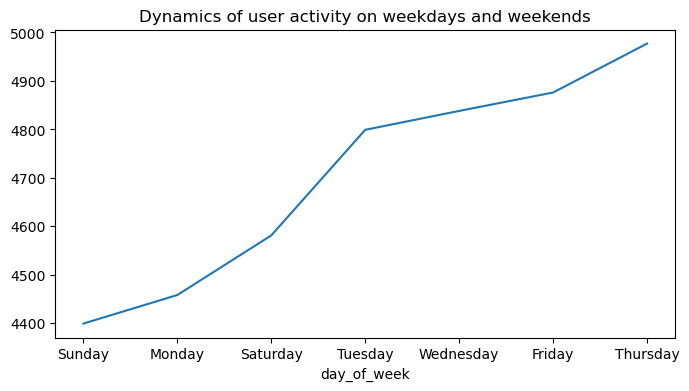

In [80]:
week_active.plot(figsize=(8,4))
plt.title('Dynamics of user activity on weekdays and weekends')

plt.show()

Key Insights from the Graphs
- There is a steady growth in both the total number of orders and the number of unique users during the analyzed period (September–October 2024).
- The dynamics of both indicators are positive, showing user base expansion and increased customer activity.
- The number of orders grows faster than the number of unique users, which may indicate an increase in purchase frequency per user.
- There are some sharp spikes in orders (end of September and end of October), likely related to marketing campaigns, discounts, or seasonal factors.
- Weekday activity analysis shows highest user activity on weekdays, especially Thursday and Friday. The lowest activity is on Sunday.
- This indicates that users are more active during the workweek, and activity decreases slightly on weekends.

Conclusion:

Overall, the service shows positive growth trends, with a clear dependency of user activity on day of the week.

#### 3.3. Popular Events and Partners

In [81]:
autumn_seg['region_name'].nunique()

79

In [82]:
total_orders=autumn_seg['order_id'].count()

In [83]:
orders_per_seg=autumn_seg.groupby('region_name')['order_id'].count().sort_values(ascending=False).head(10)
display(orders_per_seg)

region_name
Каменевский регион         47271
Североярская область       20855
Медовская область          12052
Широковская область         8739
Озернинский край            7579
Светополянский округ        4820
Малиновоярский округ        4606
Серебринская область        4477
Солнечноземская область     4232
Яблоневская область         4224
Name: order_id, dtype: int64

In [84]:
# share of orders per region
share_of_orders = (orders_per_seg / total_orders*100).round(2)
print(share_of_orders)

region_name
Каменевский регион         27.87
Североярская область       12.30
Медовская область           7.11
Широковская область         5.15
Озернинский край            4.47
Светополянский округ        2.84
Малиновоярский округ        2.72
Серебринская область        2.64
Солнечноземская область     2.50
Яблоневская область         2.49
Name: order_id, dtype: float64


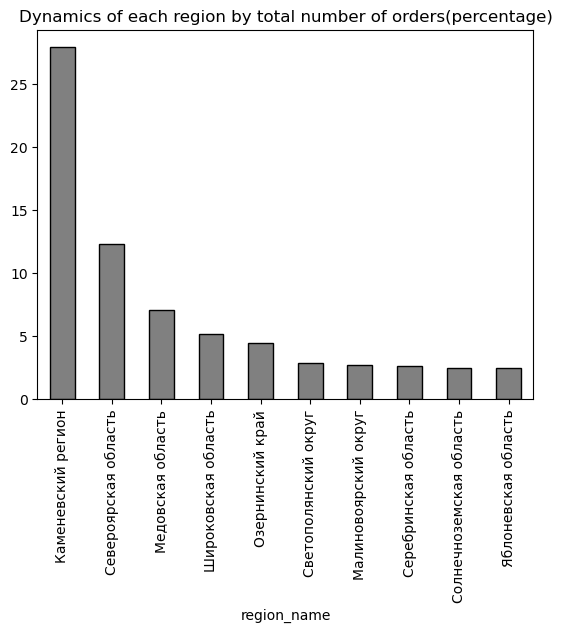

In [85]:
share_of_orders.plot(kind='bar',
                   title='Dynamics of each region by total number of orders(percentage)',
                   edgecolor='k',
                   color='grey')

plt.show()

In [86]:
region_count = autumn_seg.groupby('region_name').agg(unique_events=('event_type_main','nunique'),
                                                    count_orders = ('order_id','count')).sort_values(by='unique_events',ascending=False)
region_count.head(10)

,unique_events,count_orders
region_name,,
Горностепной регион,7,685
Солнечноземская область,7,4232
Тепляковская область,7,2488
Светополянский округ,7,4820
Озернинский край,7,7579
Горицветская область,7,3235
Серебринская область,7,4477
Зоринский регион,7,1999
Каменевский регион,7,47271


In [87]:
events_per_region=autumn_seg.groupby('region_name')['event_type_main'].nunique().sort_values(ascending=False).head(20)
display(events_per_region)

region_name
Горностепной регион          7
Солнечноземская область      7
Тепляковская область         7
Светополянский округ         7
Озернинский край             7
Горицветская область         7
Серебринская область         7
Зоринский регион             7
Каменевский регион           7
Травяная область             7
Медовская область            7
Широковская область          7
Яблоневская область          7
Североярская область         7
Ягодиновская область         7
Речиновская область          7
Лугоградская область         6
Малиновоярский округ         6
Солнечнореченская область    6
Лесодальний край             6
Name: event_type_main, dtype: int64

In [88]:
total_event = autumn_seg['event_type_main'].nunique()
print(total_event)

7


In [89]:
share_of_events = (events_per_region/total_event*100).round(2)
display(share_of_events)

region_name
Горностепной регион          100.00
Солнечноземская область      100.00
Тепляковская область         100.00
Светополянский округ         100.00
Озернинский край             100.00
Горицветская область         100.00
Серебринская область         100.00
Зоринский регион             100.00
Каменевский регион           100.00
Травяная область             100.00
Медовская область            100.00
Широковская область          100.00
Яблоневская область          100.00
Североярская область         100.00
Ягодиновская область         100.00
Речиновская область          100.00
Лугоградская область          85.71
Малиновоярский округ          85.71
Солнечнореченская область     85.71
Лесодальний край              85.71
Name: event_type_main, dtype: float64

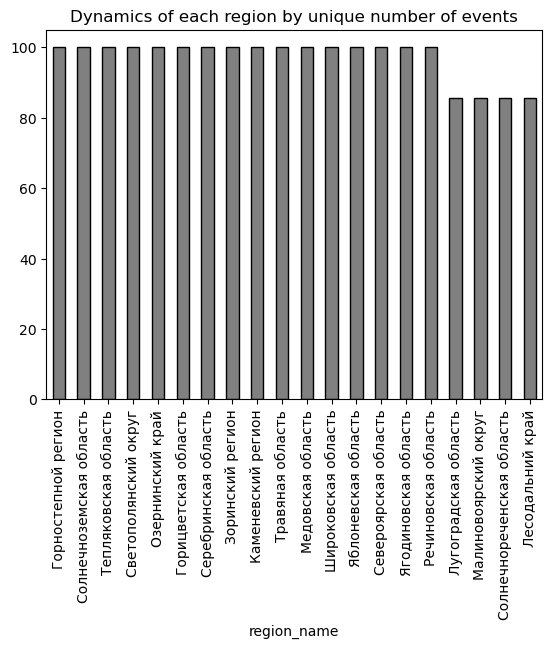

In [90]:
share_of_events.plot(kind='bar',
                    title='Dynamics of each region by unique number of events',
                    edgecolor='k',
                    color='grey')

plt.show()

In [91]:
autumn_seg['service_name'].nunique()

35

In [92]:
service_analyse=autumn_seg.groupby('service_name').agg(
                                        unique_events=('event_type_main','nunique'),
                                        tickets_purches=('tickets_count','sum'),
                                        total_revenue=('revenue','sum')).sort_values(by='total_revenue',ascending=False)
display(service_analyse)

,unique_events,tickets_purches,total_revenue
service_name,,,
Билеты без проблем,7,89909,13339547.94
Мой билет,7,52622,11668245.32
Облачко,7,40131,10887838.30
Лови билет!,7,71859,10572834.62
Весь в билетах,7,27258,9809310.33
Билеты в руки,7,73521,7688881.08
Край билетов,4,8657,3176579.76
Яблоко,7,9985,2827527.72
Прачечная,7,16333,2647691.55


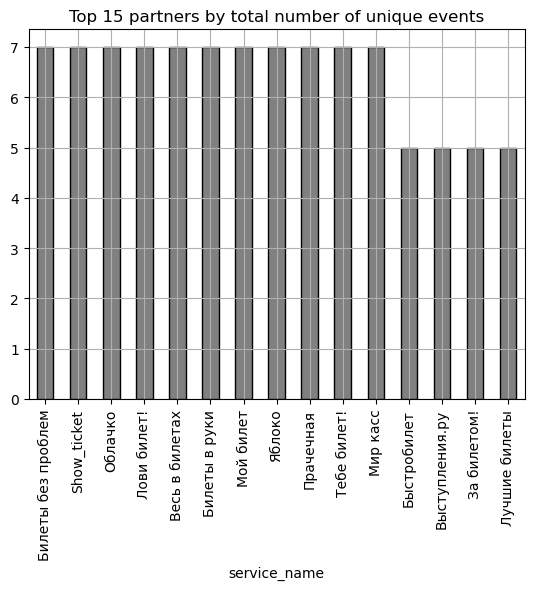

In [93]:
service_analyse['unique_events'].sort_values(ascending=False).head(15).plot(kind='bar',
                                                                           title='Top 15 partners by total number of unique events',
                                                                           edgecolor='k',
                                                                           color='grey')
plt.grid()
plt.show()

In [94]:
service_analyse['unique_events'].sort_values(ascending=False)

service_name
Билеты без проблем        7
Show_ticket               7
Облачко                   7
Лови билет!               7
Весь в билетах            7
Билеты в руки             7
Мой билет                 7
Яблоко                    7
Прачечная                 7
Тебе билет!               7
Мир касс                  7
Быстробилет               5
Выступления.ру            5
За билетом!               5
Лучшие билеты             5
Дом культуры              5
Городской дом культуры    4
Край билетов              4
Вперёд!                   4
КарандашРУ                3
Росбилет                  3
Crazy ticket!             3
Реестр                    3
Радио ticket              2
Телебилет                 2
Дырокол                   2
Тех билет                 2
Восьмёрка                 2
Шоу начинается!           2
Лимоны                    1
Билеты в интернете        1
Кино билет                1
Быстрый кассир            1
Билет по телефону         1
Зе Бест!                  1
Name: u

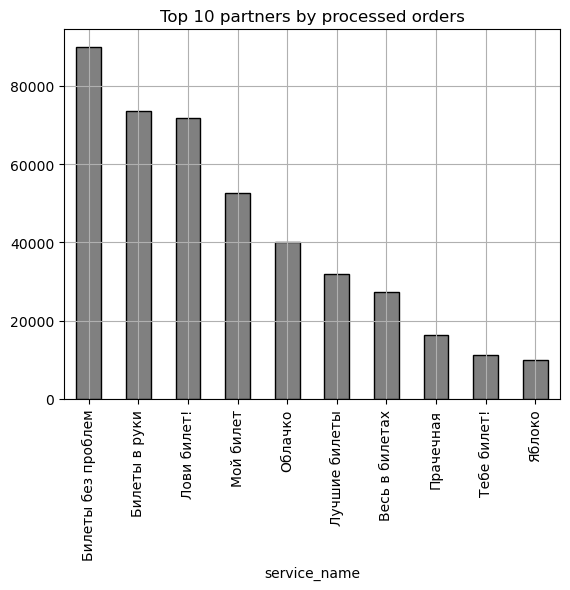

In [95]:
service_analyse['tickets_purches'].sort_values(ascending=False).head(10).plot(kind='bar',
                                                                             title='Top 10 partners by processed orders',
                                                                             edgecolor='k',
                                                                             color='grey')
plt.grid()
plt.show()

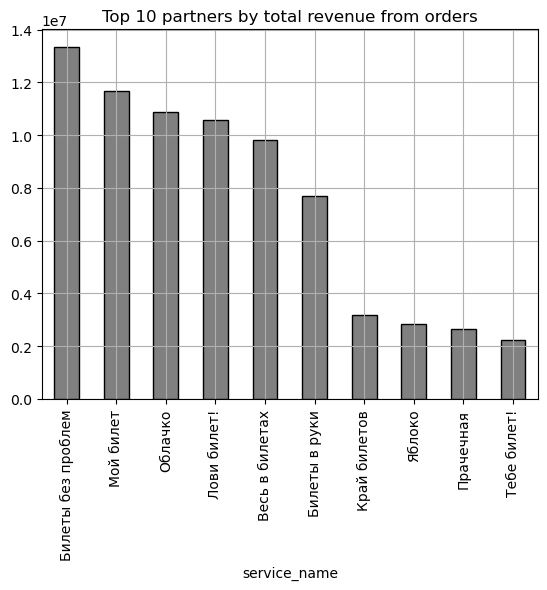

In [96]:
service_analyse['total_revenue'].sort_values(ascending=False).head(10).plot(kind='bar',
                                                                          title='Top 10 partners by total revenue from orders',
                                                                          edgecolor='k',
                                                                          color='grey')
plt.grid()
plt.show()


- Focus should be on partners with high revenue and large ticket sales — these are the most profitable and in-demand partners.
- Also note partners who organize many events, even if the average revenue per event is lower — these are the most active and stable players.

By total number of orders, the top regions are:

1. Каменевский регион — 27.87%
2. Североярская область — 12.30%
3. Медовская область — 7.11%
4. Regions with the greatest event variety:
5. Горностепной регион — 100%
6. Солнечноземская область — 100%
7. Тепляковская область — 100%
8. Светополянский округ — 100%
9. Озернинский край — 100%
10. Горицветская область — 100%
11. Серебринская область — 100%
12. Зоринский регион — 100%
13. Каменевский регион — 100%
14. Травяная область — 100%
15. Медовская область — 100%
16. Широковская область — 100%
17. Яблоневская область — 100%
18. Североярская область — 100%
19. Ягодиновская область — 100%
20. Речиновская область — 100%

From the graphs, the leading partner in all three metrics (total number of unique events, processed orders, and total revenue) is: `Билеты без проблем`

- Total revenue ranking: `Мой билет`,`Облачко` and `Лови билет!`
- Processed orders ranking: `Билеты в руки`,`Лови билет!`

Partners with 100% of total unique events:
1. Билеты без проблем
2. Show_ticket
3. Облачко
4. Лови билет!
5. Весь в билетах
6. Билеты в руки
7. Мой билет
8. Яблоко
9. Прачечная
10. Тебе билет!
11. Мир касс

## Step 4: Statistical Data Analysis

In [97]:
mobile_group = autumn_seg[autumn_seg['device_type_canonical']=='mobile']
desktop_group = autumn_seg[autumn_seg['device_type_canonical']=='desktop']

###### Hypothesis Testing – Average Number of Orders

In [98]:
mobile_orders_count = mobile_group.groupby('user_id')['order_id'].count()
desktop_orders_count = desktop_group.groupby('user_id')['order_id'].count()

In [99]:
print(mobile_orders_count.var())
print(desktop_orders_count.var())


4684.813060462987
1312.9025401692134


- The variances are very different, so we use Welch’s t-test.
##### Null and alternative hypotheses:

- Null hypothesis (H0): The average number of orders per user of the mobile app does not differ from the average number of orders per desktop user.

- Alternative hypothesis (H1): The average number of orders per user of the mobile app is higher than for desktop users.

In [100]:
# The average number of orders per user of the mobile app is higher than for desktop users.

alpha=0.05

results = st.ttest_ind(
                  mobile_orders_count,
                  desktop_orders_count,
                  equal_var=False,
                  alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print('We fail to reject the null hypothesis')

p-value: 0.0008257937141742472
We reject the null hypothesis


In [101]:
mobile_orders_count.describe()

count    14195.000000
mean         9.512364
std         68.445694
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4361.000000
Name: order_id, dtype: float64

In [102]:
desktop_orders_count.describe()

count    4883.000000
mean        7.076797
std        36.233997
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1510.000000
Name: order_id, dtype: float64

- I used Welch’s t-test to check the hypothesis about the equality of means between two samples. The significance level is set at 0.05.

- p-value = 0.0008246, which is less than 0.05.

- This means that the average number of orders per mobile app user is higher than for desktop users.

###### Hypothesis Testing – Average Time Between Orders

- Null hypothesis (H0): The average time between orders of mobile app users does not differ from the average time between orders of desktop users.

- Alternative hypothesis (H1): The average time between orders of mobile app users is higher than for desktop users.

In [103]:
# mobile
mobile_time_diff = (
    mobile_group.sort_values(['user_id', 'created_dt_msk'])
    .groupby('user_id')['created_dt_msk']
    .diff()             # diference between rows
    .dt.days
)


In [104]:
desktop_time_diff = (
    desktop_group.sort_values(['user_id','created_dt_msk'])
    .groupby('user_id')['created_dt_msk'].diff().dt.days)

In [105]:
mobile_time_diff = mobile_time_diff.dropna()
desktop_time_diff = desktop_time_diff.dropna()

The columns `mobile_time_diff` and `desktop_time_diff` contain `NaN` values, which were removed..

In [106]:
print(mobile_time_diff.var())
print(desktop_time_diff.var())

24.900864189990003
30.263582737733547


Variances are not very different, so we could use Student’s t-test, but Welch’s t-test was still used.

In [107]:
alpha=0.05

results = st.ttest_ind(
           mobile_time_diff,
           desktop_time_diff,
        equal_var=False,
        alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis')
else:
    print('We fail to reject the null hypothesis')

p-value: 0.9999999998986819
We fail to reject the null hypothesis



- p-value = 0.9999999999, which is higher than 0.05.
This means we cannot reject the null hypothesis.

- Conclusion: The average time between orders of mobile app users does not differ from that of desktop users.


# Step 5: Overall Conclusion and Recommendations

During this study, we analyzed ticket booking data on Yandex Afisha for the period from June 1 to October 31, 2024. The data included all ticket orders made from two types of devices — mobile and desktop, as well as information about events, including city, region, and venue details.

The main goal of the study was to identify insights about changes in user preferences and event popularity in autumn 2024, and to test hypotheses about differences in behavior between mobile and desktop users.

##### ОKey Findings and Results:

- From June to October, there is a steady growth in orders (from 32,845 to 99,914).
- The number of orders grows faster than the number of unique users, indicating an increase in purchase frequency.
- Mobile users place more orders, while the average time between purchases is similar for mobile and desktop users.
- Highest revenue comes from concerts, followed by Christmas tree events, stand-up, and theater.
- In autumn, interest grows in sports and theater, while the average ticket price decreases.
- The partner “Билеты без проблем” leads in number of orders and revenue.
- Order peaks correspond to marketing campaigns or seasonal events.
#### Recommendations:
- Focus on mobile users to increase engagement.
- Plan promotions on key days to match peaks in demand.
- Monitor average ticket price to optimize revenue.
- Develop popular event categories based on user preferences.